# Práctica guiada: Procesamiento digital de imágenes

Esta práctica funciona como puente entre los cuadernos conceptuales y el laboratorio aplicado. La propuesta es que completes código, pruebes variantes y expliques con tus palabras qué decisiones tomaste.

## Objetivos

- Recuperar ideas de color, canales, bordes e intensidad.
- Practicar lectura de imágenes con `OpenCV`.
- Resolver consignas breves con andamiaje.
- Prepararte para el laboratorio de segmentación y la actividad integradora.


In [18]:
# Permite trabajar con rutas y nombres de archivos de forma más ordenada.
from pathlib import Path

# OpenCV: lectura, escritura y procesamiento de imágenes.
import cv2

# Matplotlib: para mostrar imágenes y gráficos.
import matplotlib.pyplot as plt

# NumPy: manejo de matrices y arreglos numéricos.
import numpy as np

# Scikit-image: aporta imágenes de ejemplo para la práctica.
import skimage as ski


# Muestra una o varias imágenes en una misma figura con sus títulos.
def mostrar_imagenes(imagenes, titulos, cmap=None, figsize=(14, 4)):
    # Crea una fila de subgráficos, uno por cada imagen.

    fig, axes = plt.subplots(1, len(imagenes), figsize=figsize)

    # Si hay una sola imagen, convierte axes en lista para recorrerlo igual que en los demás casos.
    if len(imagenes) == 1:
        axes = [axes]

    # Recorre cada eje, imagen y título para mostrarlos juntos.
    for ax, imagen, titulo in zip(axes, imagenes, titulos):
        # Si la imagen es de 2 dimensiones, se interpreta como escala de grises.
        if imagen.ndim == 2:
            ax.imshow(imagen, cmap=cmap or "gray")
        else:
            # Si tiene más dimensiones, se muestra como imagen color.
            ax.imshow(imagen)

        # Coloca el título correspondiente y oculta los ejes.
        ax.set_title(titulo)
        ax.axis("off")

    # Ajusta los espacios entre imágenes para que no se superpongan.
    plt.tight_layout()
    plt.show()


# Genera una imagen binaria según un umbral.
def segmentar_por_umbral(imagen, umbral):
    # Crea una máscara vacía del mismo tamaño que la imagen original.
    mascara = np.zeros_like(imagen, dtype=np.uint8)

    # Los píxeles mayores al umbral se ponen en blanco.
    mascara[imagen > umbral] = 255

    # Devuelve la imagen segmentada.
    return mascara


In [19]:
# Define la carpeta base donde se guardarán las imágenes de práctica.
base = Path(".")

# Guarda una imagen de ejemplo como "paisaje.png".
# Se convierte de RGB a BGR porque OpenCV trabaja internamente con ese orden de colores.
cv2.imwrite(str(base / "paisaje.png"), cv2.cvtColor(ski.data.astronaut(), cv2.COLOR_RGB2BGR))

# Guarda una imagen de texto en escala de grises para trabajar detección de bordes.
cv2.imwrite(str(base / "texto.png"), ski.data.page())

# Guarda una imagen de monedas en escala de grises para practicar segmentación por umbral.
cv2.imwrite(str(base / "monedas.png"), ski.data.coins())

# Muestra un mensaje para confirmar que los archivos quedaron listos.
print("Archivos de práctica listos: paisaje.png, texto.png y monedas.png")


Archivos de práctica listos: paisaje.png, texto.png y monedas.png


## Ejercicio 1: Color y canales

Completá los pasos.

1. Cargá `paisaje.png` con `OpenCV`.
2. Convertí la imagen a `RGB`.
3. Extraé los tres canales.
4. Mostrá la imagen original y los canales por separado.
5. Escribí una observación breve sobre qué zonas se destacan en cada canal.


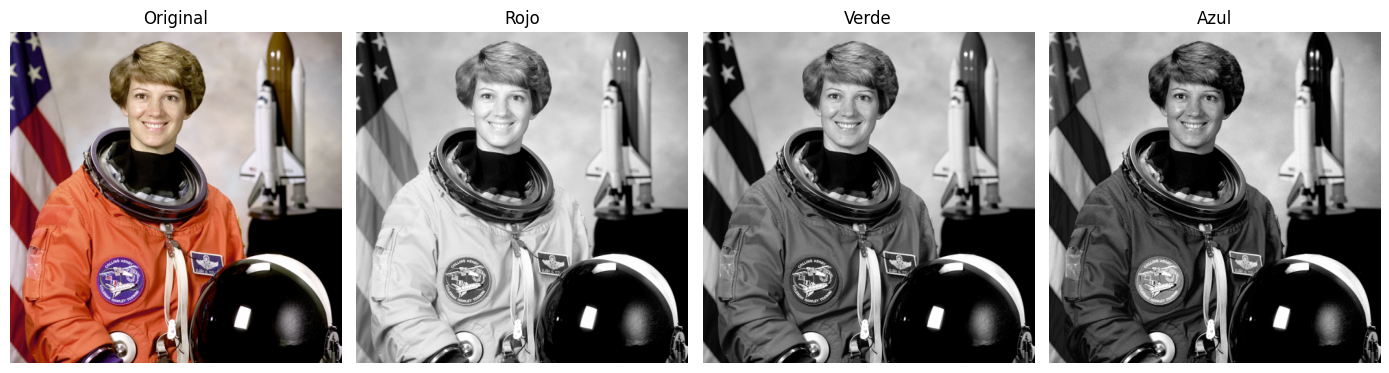

In [20]:
# 1. Cargar la imagen desde el archivo usando OpenCV.
# OpenCV la lee en formato BGR, no en RGB.
img_bgr = cv2.imread("paisaje.png")

# 2. Convertir la imagen de BGR a RGB para visualizarla correctamente con matplotlib.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. Extraer por separado los canales rojo, verde y azul de la imagen RGB.
# En una imagen color, cada canal representa la intensidad de ese color en cada píxel.
canal_rojo = img_rgb[:, :, 0]
canal_verde = img_rgb[:, :, 1]
canal_azul = img_rgb[:, :, 2]

# 4. Mostrar la imagen original y cada canal por separado.
# La primera imagen se ve en color porque tiene 3 canales.
# Los canales individuales se muestran en escala de grises:
# cuanto más claro se ve un píxel, mayor es la intensidad de ese color en esa zona.
mostrar_imagenes(
    [img_rgb, canal_rojo, canal_verde, canal_azul],
    ["Original", "Rojo", "Verde", "Azul"],
)



In [21]:
# Escribí acá tu observación sobre los canales.
# ¿Qué zonas aparecen más brillantes en cada uno?

observacion_canales = (
    "En el canal rojo se destacan más la piel y algunas zonas de la ropa; "
    "en el canal verde se observan con más intensidad partes del fondo y tonos intermedios; "
    "en el canal azul resaltan menos las zonas cálidas y se hacen más visibles las regiones frías o claras. "
    "Esto muestra que cada canal aporta información distinta sobre la imagen."
    "Las zonas más brillantes en un canal son las que tienen mayor presencia de ese color."
    "Como la imagen de ejemplo es una foto color, algunas regiones se destacan más en unos canales que en otros."
)
print(observacion_canales)


En el canal rojo se destacan más la piel y algunas zonas de la ropa; en el canal verde se observan con más intensidad partes del fondo y tonos intermedios; en el canal azul resaltan menos las zonas cálidas y se hacen más visibles las regiones frías o claras. Esto muestra que cada canal aporta información distinta sobre la imagen.Las zonas más brillantes en un canal son las que tienen mayor presencia de ese color.Como la imagen de ejemplo es una foto color, algunas regiones se destacan más en unos canales que en otros.


## Ejercicio 2: Recorte y redimensionado

1. Definí una región de interés de `100 x 100` píxeles dentro de `paisaje.png`.
2. Redimensioná ese recorte a `220 x 220` píxeles.
3. Armá un mosaico `2 x 2` con el recorte redimensionado.
4. Explicá, con una frase, la diferencia entre recortar y redimensionar.


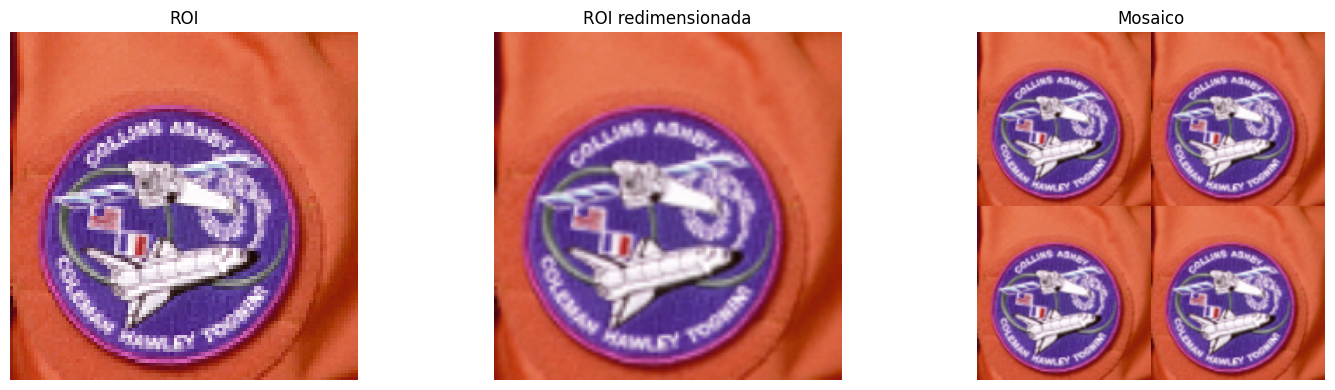

In [22]:
# Definir los índices de una región de interés de 100 x 100 píxeles.
# Se elige un sector de la ropa para recortar la zona del parche violeta.
y1, y2 = 327, 427
x1, x2 = 125, 225
#y1:y2 define la altura del recorte 
#x1:x2 define el ancho del recorte
#En ese caso, el máximo seguro sería:
# y1 hasta 412, porque 412 + 100 = 512
# x1 hasta 412, porque 412 + 100 = 512


# Recorta la región de interés elegida dentro de la imagen original.
roi = img_rgb[y1:y2, x1:x2]

# Redimensiona el recorte a 220 x 220 píxeles para verlo más grande.
roi_grande = cv2.resize(roi, (220, 220))


# Armar dos filas con la misma ROI redimensionada.
fila_superior = np.hstack((roi_grande, roi_grande))#une imágenes en forma horizontal, una al lado de la otra.
fila_inferior = np.hstack((roi_grande, roi_grande))

# Unir ambas filas para formar un mosaico 2 x 2.
mosaico = np.vstack((fila_superior, fila_inferior))#une imágenes en forma vertical, una debajo de la otra.


mostrar_imagenes(
    [roi, roi_grande, mosaico],
    ["ROI", "ROI redimensionada", "Mosaico"],
    figsize=(15, 4),
)

#¿Por qué usamos roi_grande y no roi?
# porque ya está redimensionada a 220 x 220
# así el mosaico se ve más claro y más grande
# si usara roi, también funcionaría, pero se vería más pequeño


In [23]:
# Explicación breve.
explicacion_geometria = (
    "Recortar consiste en seleccionar solo una parte de la imagen original, "
    "mientras que redimensionar cambia el tamaño de una imagen o recorte sin cambiar su contenido."
    "La ROI mantiene la calidad original del recorte, mientras que la imagen redimensionada puede perder nitidez al ampliarse."
    "El mosaico conserva la misma calidad que la ROI redimensionada, ya que solo repite esa imagen."

)
print(explicacion_geometria)

conclusion_ejercicio_2 = (
    "La ROI mantiene la calidad original del recorte, mientras que la imagen redimensionada "
    "puede perder nitidez al ampliarse. El mosaico conserva esa misma calidad, porque está "
    "formado por repeticiones de la ROI redimensionada."
)
print(conclusion_ejercicio_2)




Recortar consiste en seleccionar solo una parte de la imagen original, mientras que redimensionar cambia el tamaño de una imagen o recorte sin cambiar su contenido.La ROI mantiene la calidad original del recorte, mientras que la imagen redimensionada puede perder nitidez al ampliarse.El mosaico conserva la misma calidad que la ROI redimensionada, ya que solo repite esa imagen.
La ROI mantiene la calidad original del recorte, mientras que la imagen redimensionada puede perder nitidez al ampliarse. El mosaico conserva esa misma calidad, porque está formado por repeticiones de la ROI redimensionada.


## Ejercicio 3: Bordes y umbralización

1. Cargá `texto.png` en escala de grises.
2. Aplicá `Canny` con dos pares de umbrales distintos.
3. Cargá `monedas.png` en escala de grises.
4. Segmentá la imagen de monedas con al menos dos umbrales.
5. Compará los resultados y explicá cuál te parece más útil.


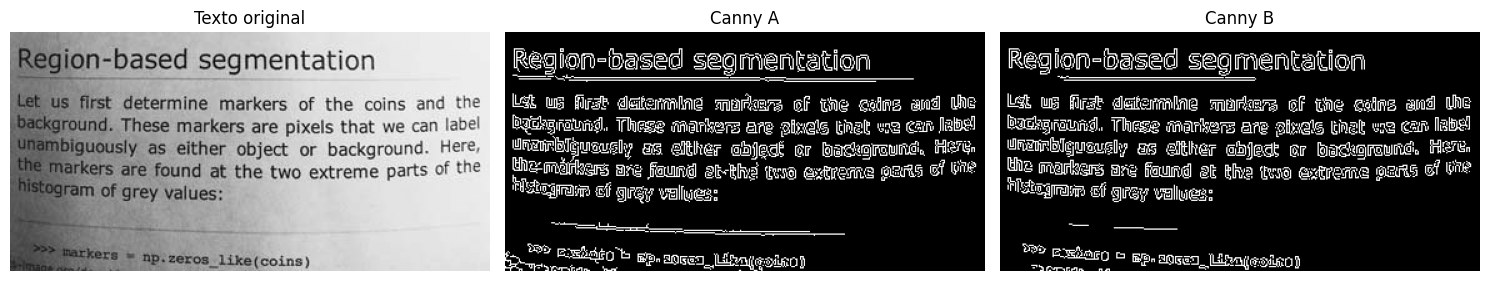

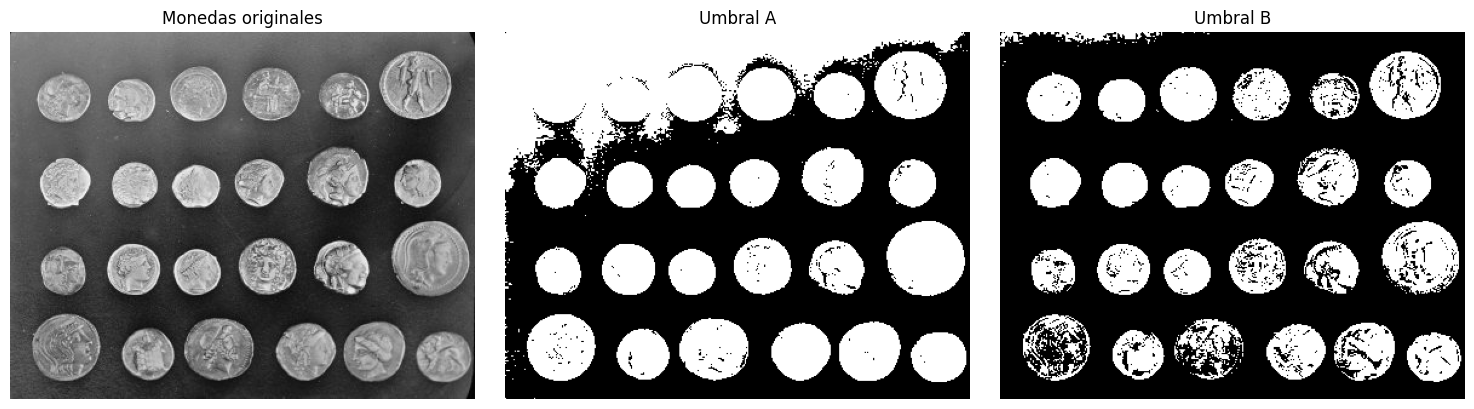

In [24]:
# Carga la imagen de texto en escala de grises para trabajar detección de bordes.
img_texto = cv2.imread("texto.png", cv2.IMREAD_GRAYSCALE)
#cv2.IMREAD_GRAYSCALE indica que se cargue con un solo canal de intensidad, no en color.


# Aplicar Canny con dos pares de umbrales distintos para comparar la detección de bordes.
# El primer caso detecta más bordes; el segundo es más exigente y detecta menos.
canny_a = cv2.Canny(img_texto, 50, 150)#detecta bordes a partir de cambios de intensidad.
canny_b = cv2.Canny(img_texto, 100, 200)
#Los dos números son umbrales que controlan qué tan sensible será la detección.
#Con umbrales más bajos: se detectan más bordes, también puede aparecer más ruido
#Con umbrales más altos: se detectan menos bordes, suelen quedar solo los contornos más marcados

# Mostrar la imagen original y los dos resultados de Canny para compararlos visualmente.
mostrar_imagenes(
    [img_texto, canny_a, canny_b],
    ["Texto original", "Canny A", "Canny B"],
    figsize=(15, 4),
)

# Cargar la imagen de monedas en escala de grises para aplicar segmentación por umbral.
img_monedas = cv2.imread("monedas.png", cv2.IMREAD_GRAYSCALE)


# Aplicar dos umbrales diferentes para comparar cómo cambia la segmentación.
# Un umbral más bajo deja pasar más zonas claras; uno más alto selecciona solo las más intensas.
seg_a = segmentar_por_umbral(img_monedas, 90)#90 es un umbral más bajo: detecta más zonas claras, puede incluir más fondo o ruido
seg_b = segmentar_por_umbral(img_monedas, 130)#130 es un umbral más alto: selecciona menos píxeles, suele quedarse con las zonas más brillantes


# Mostrar la imagen original de monedas y las dos segmentaciones para comparar sus resultados.
mostrar_imagenes(
    [img_monedas, seg_a, seg_b],
    ["Monedas originales", "Umbral A", "Umbral B"],
    figsize=(15, 4),
)


## Sección extra: repetir la técnica utilizando otras imágenes

Esta sección permite volver a aplicar las mismas ideas sobre imágenes donde los efectos suelen verse con más claridad.

- `coffee`: buena para observar canales de color.
- `camera`: buena para bordes y contraste en escala de grises.
- `coins`: buena para segmentación por umbral.



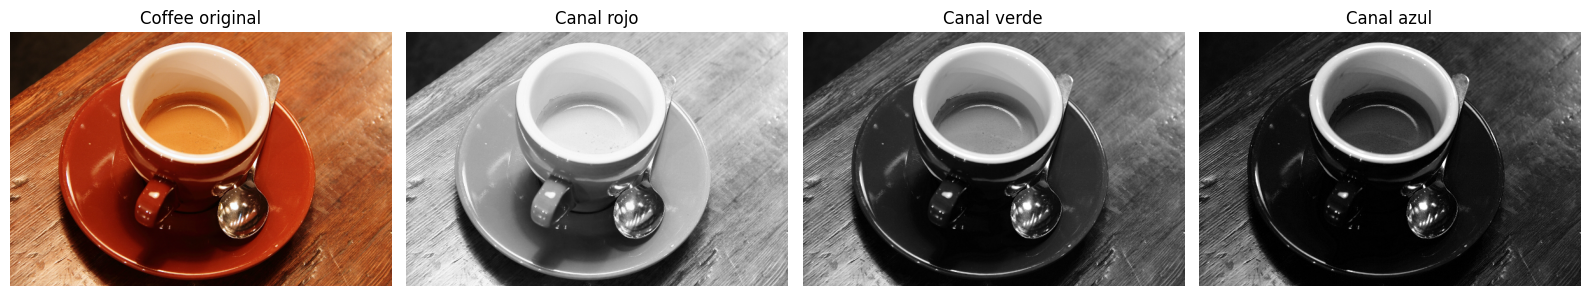

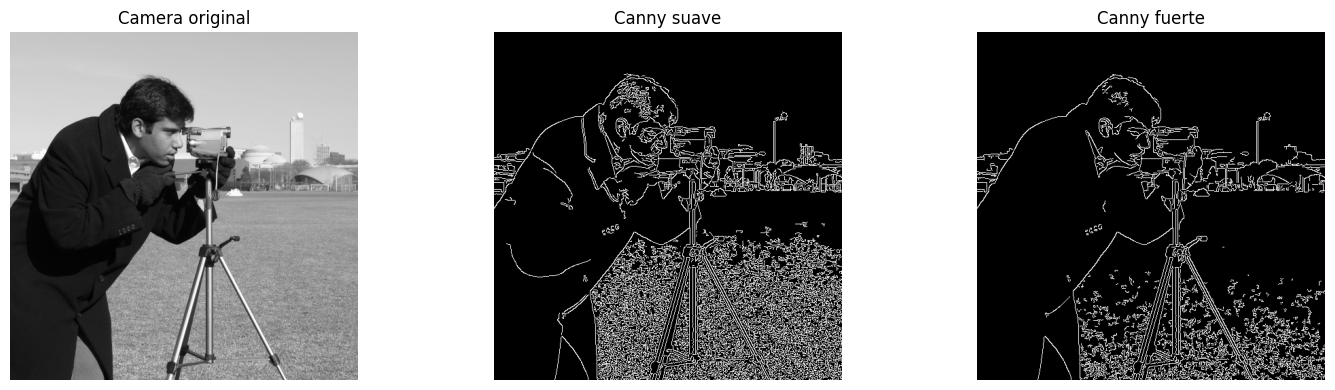

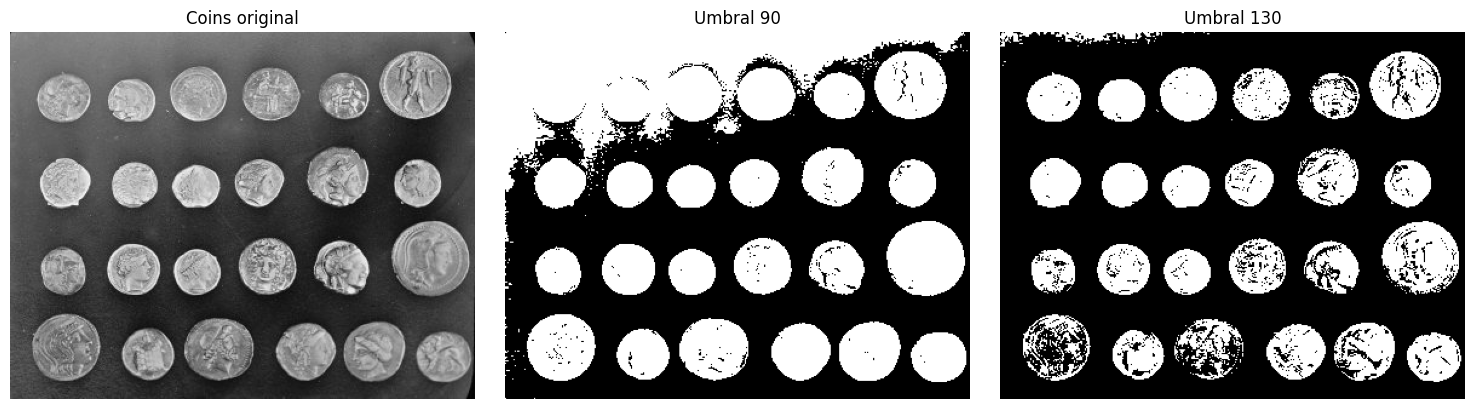

In [25]:
# Cargar una imagen color donde los canales se distinguen bien.
img_color = ski.data.coffee()

# Extraer los tres canales para compararlos por separado.
canal_r = img_color[:, :, 0]
canal_g = img_color[:, :, 1]
canal_b = img_color[:, :, 2]

# Mostrar la imagen original y sus canales.
mostrar_imagenes(
    [img_color, canal_r, canal_g, canal_b],
    ["Coffee original", "Canal rojo", "Canal verde", "Canal azul"],
    figsize=(16, 4),
)

# Cargar una imagen en grises con bordes marcados.
img_bordes = ski.data.camera()

# Aplicar Canny con dos configuraciones para comparar sensibilidad.
bordes_suaves = cv2.Canny(img_bordes, 40, 120)
bordes_fuertes = cv2.Canny(img_bordes, 100, 220)

# Mostrar la imagen y los bordes detectados.
mostrar_imagenes(
    [img_bordes, bordes_suaves, bordes_fuertes],
    ["Camera original", "Canny suave", "Canny fuerte"],
    figsize=(15, 4),
)

# Reutilizar una imagen clásica para practicar segmentación.
img_segmentacion = ski.data.coins()

# Probar dos umbrales para ver cómo cambia la separación entre monedas y fondo.
segmentacion_a = segmentar_por_umbral(img_segmentacion, 90)
segmentacion_b = segmentar_por_umbral(img_segmentacion, 130)

# Comparar la imagen original con ambas segmentaciones.
mostrar_imagenes(
    [img_segmentacion, segmentacion_a, segmentacion_b],
    ["Coins original", "Umbral 90", "Umbral 130"],
    figsize=(15, 4),
)


## Cierre breve

Antes de pasar al laboratorio, revisá si podés responder estas preguntas:

- ¿cuándo conviene mirar canales por separado?
Conviene mirar los canales por separado cuando queremos analizar cómo aporta cada color a la imagen o detectar qué zonas se destacan más en rojo, verde o azul.

- ¿qué cambia al modificar los umbrales de `Canny`?
Al modificar los umbrales de Canny cambia la sensibilidad de detección de bordes: con valores más bajos aparecen más bordes, y con valores más altos se conservan solo los más marcados.

- ¿por qué una segmentación por umbral puede funcionar bien en una imagen y mal en otra?
Una segmentación por umbral puede funcionar bien cuando el objeto y el fondo tienen intensidades diferentes, pero puede fallar si sus tonos son parecidos, si hay sombras, ruido o iluminación poco uniforme.
